Method 1: Using auto_load_or_create

>>> First call (will train):
Searching for config with hash: 17b06b7904ef6c26...
Searching for matching config... ./saved_configs and hash 17b06b7904ef6c26
Search directory does not exist: saved_configs
{'N_units': 20, 'Win_type': 'sparse', 'N_wash': 5, 'upsample': 1, 'bias_in': 0.1, 'bias_out': 1.0, 'norm_method': 'range', 'connect': 3, 'dt': 0.01, 'observed_idx': None, 'update_reservoir': True, 'update_state': True, 'Wout_svd': False, 'N_dim': None, 't_train': None, 't_val': None, 't_test': None, 'N_func_evals': 40, 'N_grid': 5, 'N_folds': 8, 'N_initial_rand': 0, 'N_split': 5, 'rho_range': (0.2, 0.8), 'sigma_in_range': (-0.30103, 1.69897), 'tikh_range': (1e-06, 1e-09, 1e-12), 'noise': 0.01, 'seed': 0, 'training_data_filename': None}
Training ESN model...


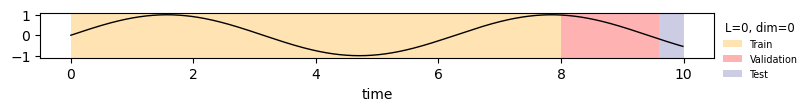


 ----------------- HYPERPARAMETER SEARCH ------------------
 5x5 grid and 15 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 
1	 2.000e-01	 5.000e-01	 1.000e-12	 -0.7887
2	 2.000e-01	 1.581e+00	 1.000e-06	 -0.7454
3	 2.000e-01	 5.000e+00	 1.000e-12	 -0.7437
4	 2.000e-01	 1.581e+01	 1.000e-09	 -0.7593
5	 2.000e-01	 5.000e+01	 1.000e-06	 -0.7238
6	 3.500e-01	 5.000e-01	 1.000e-06	 -0.6616
7	 3.500e-01	 1.581e+00	 1.000e-06	 -0.7359
8	 3.500e-01	 5.000e+00	 1.000e-06	 -0.6808
9	 3.500e-01	 1.581e+01	 1.000e-09	 -0.7855
10	 3.500e-01	 5.000e+01	 1.000e-09	 -0.7235
11	 5.000e-01	 5.000e-01	 1.000e-09	 -0.6740
12	 5.000e-01	 1.581e+00	 1.000e-06	 -0.6564
13	 5.000e-01	 5.000e+00	 1.000e-06	 -0.6993
14	 5.000e-01	 1.581e+01	 1.000e-06	 -0.7909
15	 5.000e-01	 5.000e+01	 1.000e-09	 -0.7154
16	 6.500e-01	 5.000e-01	 1.000e-06	 -0.6476
17	 6.500e-01	 1.581e+00	 1.000e-06	 -0.7071
18	 6.500e-01	 5.000e+00	 1.000e-06	 -0.6901
19	 6.500e-01	 1.581e+01	 1.000e-09	 -0.7800
20	 6.500

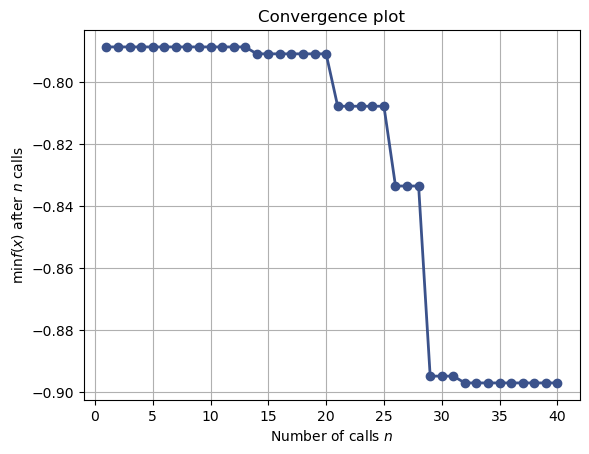

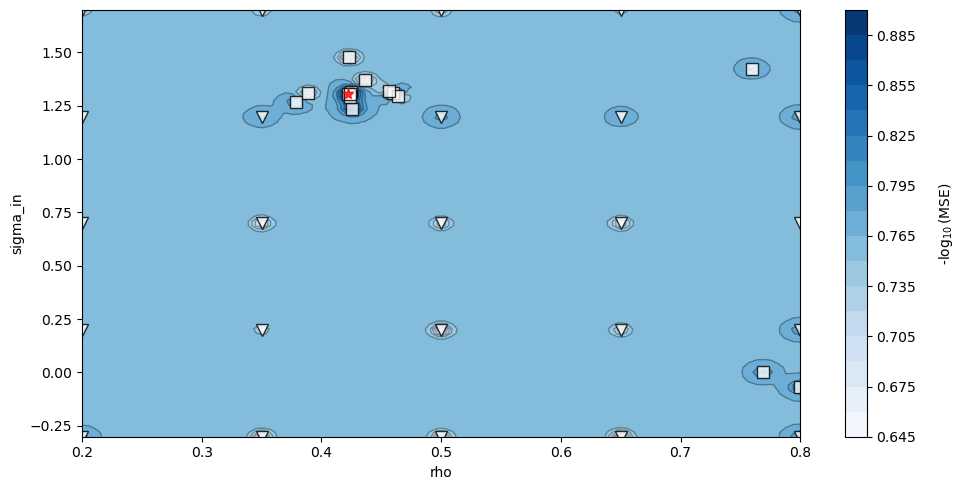

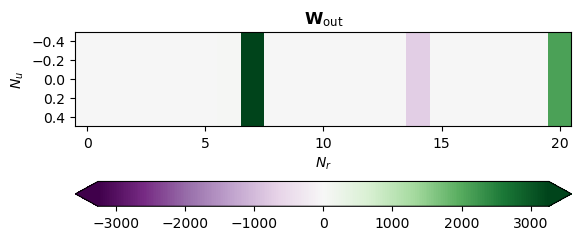

In [1]:
"""
Example: Automatic config loading with ESN_model
"""
import numpy as np
from config.esn_config import auto_load_or_create, save_esn_config, find_matching_config, ESNConfig
from models_data_driven import ESN_model


# ========== Method 1: Using auto_load_or_create (Recommended) ==========
print("=" * 60)
print("Method 1: Using auto_load_or_create")
print("=" * 60)

t = np.linspace(0, 10, 1000)
data = np.sin(t)[np.newaxis, :, np.newaxis]

# First run: trains new model
print("\n>>> First call (will train):")
esn1 = auto_load_or_create(
    data=data,
    dt=0.01,
    N_units=20,
    config_dir="./saved_configs",
    auto_save=True,
    plot_training=False
)

# Second run: loads existing model (fast!)
print("\n>>> Second call (will load from cache):")
esn2 = auto_load_or_create(
    data=data,
    dt=0.01,
    N_units=20,
    config_dir="./saved_configs",
    auto_save=True,
    plot_training=False
)




In [2]:

# Verify they're the same
print(f"\n✓ Both models identical:  {np.allclose(esn1.Wout, esn2.Wout)}")
print(f"\n✓ Both models identical:  {np.allclose(esn1.W.toarray(), esn2.W.toarray())}")
print(f"\n✓ Both models identical:  {np.allclose(esn1.Win.toarray(), esn2.Win.toarray())}")
print(f"\n✓ Both models identical:  {np.allclose(esn1.seed, esn2.seed)}")



✓ Both models identical:  True

✓ Both models identical:  True

✓ Both models identical:  True

✓ Both models identical:  True


In [3]:
esn1.seed

0

In [4]:

psi1, _ = esn1.time_integrate(Nt=100)  # Just to show no errors occur
psi2, _ = esn2.time_integrate(Nt=100)  # Just to show no errors occur

In [5]:
psi1.shape, psi2.shape

((100, 21, 1), (100, 21, 1))

In [6]:

print(f"Predictions identical: {np.allclose(psi1, psi2)}")

Predictions identical: True


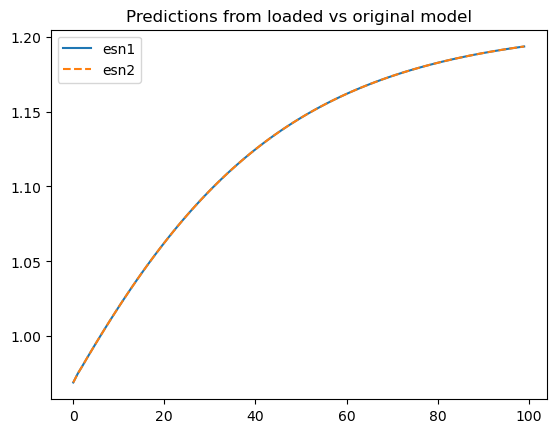

In [7]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(psi1[:, 0, 0], label='esn1')
plt.plot(psi2[:, 0, 0], '--', label='esn2')
plt.legend()
plt.title('Predictions from loaded vs original model')
plt.show()

In [8]:


# ========== Method 2: Manual config management ==========
print("\n" + "=" * 60)
print("Method 2: Manual config management")
print("=" * 60)

# Check if config exists
init_params = {
    'data': data,
    'dt': 0.01,
    'N_units':  50,
    'rho': 0.6,
    'sigma_in': 1.5,
}


query_config = ESNConfig.from_init_params(**init_params)
query_hash = query_config.to_hash()


matching_path = find_matching_config("./saved_configs", "esn_" + query_hash)

if matching_path:
    print(f"\n>>> Found existing config at: {matching_path}")
    config = ESNConfig.load_complete(matching_path)
    esn3 = config.to_esn_model(data=data)
    print("✓ Model loaded successfully")
else:
    print("\n>>> No matching config, training new model...")
    
    esn3 = ESN_model(data=data, dt=0.01, N_units=50, rho=0.6, 
                     sigma_in=1.5, plot_training=False)
    save_esn_config(esn3, save_dir="./saved_configs", name="esn_" + query_hash)




Method 2: Manual config management
Configuration loaded from saved_configs/17b06b7904ef6c26
Checking saved_configs/17b06b7904ef6c26: saved hash = 5abf62803f1a3cec
✗ No matching config found

>>> No matching config, training new model...
Training ESN model...
seed 0 	 Optimal hyperparameters: [0.2, 0.012007663255868606], 1e-12, MSE: -0.8475650720407136
Configuration saved to saved_configs/esn_fd1f269187c95c3b
Trained data saved to saved_configs/esn_fd1f269187c95c3b/trained_matrices.npz
✓ Saved ESN config:  esn_fd1f269187c95c3b


In [9]:

# ========== Method 4: List all saved configs ==========
print("\n" + "=" * 60)
print("Method 4: List all saved configs")
print("=" * 60)

from config.esn_config import list_saved_configs

configs = list_saved_configs("./saved_configs", verbose=True)
print(f"\n✓ Total configs found: {len(configs)}")




Method 4: List all saved configs
Configuration loaded from saved_configs/17b06b7904ef6c26

17b06b7904ef6c26:
  Path: saved_configs/17b06b7904ef6c26
  N_units: 20
  N_dim: 1
  dt:  0.01
Configuration loaded from saved_configs/esn_fd1f269187c95c3b

esn_fd1f269187c95c3b:
  Path: saved_configs/esn_fd1f269187c95c3b
  N_units: 50
  N_dim: 1
  dt:  0.01

✓ Total configs found: 2


In [10]:
configs

[{'directory': PosixPath('saved_configs/17b06b7904ef6c26'),
  'name': '17b06b7904ef6c26',
  'N_units': 20,
  'dt': 0.01,
  'training_data_filename': None},
 {'directory': PosixPath('saved_configs/esn_fd1f269187c95c3b'),
  'name': 'esn_fd1f269187c95c3b',
  'N_units': 50,
  'dt': 0.01,
  'training_data_filename': None}]